# Cycle 5

Optimisation des hyperparamètres du modèle + fonction évaluation métier

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import re
import utils
import mlflow

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [3]:
application = pd.read_csv('../data/rafined/application.csv', sep=',')

In [4]:
X_train, X_test, y_train, y_test = utils.split_train_data(application, 'app_TARGET')

numeric_cols = X_train.select_dtypes(include=['int64', 'int32']).columns
X_train[numeric_cols] = X_train[numeric_cols].astype('float64')
X_test[numeric_cols] = X_test[numeric_cols].astype('float64')
X_train.columns = [re.sub(r'[ \[\]\{\}:",]', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[ \[\]\{\}:",]', '_', col) for col in X_test.columns]

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, make_scorer

def optimize_business_cost(y_true, y_pred_proba, fn_weight=10, fp_weight=1):

    thresholds = np.linspace(0.01, 0.99, 99)
    min_cost = float('inf')

    for t in thresholds:
        y_pred = (y_pred_proba >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        cost = (fn * fn_weight) + (fp * fp_weight)

        if cost < min_cost:
            min_cost = cost

    # On retourne le coût en négatif car RandomizedSearchCV cherche à maximiser
    return -min_cost

business_scorer = make_scorer(optimize_business_cost, response_method='predict_proba')

In [6]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import mlflow
import warnings
import datetime
import scipy.stats as stats

warnings.filterwarnings("ignore")

mlflow.set_experiment("Payment_fault_classification")
mlflow.sklearn.autolog()

mlflow.end_run()

neg_count, pos_count = y_train.value_counts()
scale_weight = neg_count / pos_count
lightgbm_model = LGBMClassifier(scale_pos_weight=scale_weight)

param_distributions = {
    'model__n_estimators': stats.randint(100, 800),
    'model__learning_rate': stats.loguniform(0.01, 0.3),
    'model__num_leaves': stats.randint(20, 150),
    'model__max_depth': stats.randint(3, 12),
    'model__min_child_samples': stats.randint(10, 100),
    'model__colsample_bytree': stats.uniform(0.5, 0.5),
    'model__subsample': stats.uniform(0.5, 0.5),
    'model__reg_alpha': stats.loguniform(1e-4, 10.0),
    'model__reg_lambda': stats.loguniform(1e-4, 10.0),
}

run_name = "Optimization_LGBM_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
with mlflow.start_run(run_name=run_name) as parent_run:

    mlflow.set_tags({
        'dataset': 'rafined',
        'execution_type': 'hyperparameter_search_with_custom_scoring',
        'model_name': lightgbm_model
    })

    scoring = {
        'business_cost': business_scorer,
        'auc': 'roc_auc',
    }

    random_search = RandomizedSearchCV(
        estimator=lightgbm_model,
        param_distributions=param_distributions,
        n_iter=10,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        refit='business_cost',
        n_jobs=-1,
        random_state=42
    )

    print("Début de l'optimisation des hyperparamètres...")

    random_search.fit(X_train, y_train)

    print(f"Meilleurs paramètres trouvés : {random_search.best_params_}")
    print(f"Meilleur score F1 (CV) : {random_search.best_score_}")

Début de l'optimisation des hyperparamètres...
[LightGBM] [Warning] Unknown parameter: model__n_estimators
[LightGBM] [Warning] Unknown parameter: model__n_estimators
[LightGBM] [Warning] Unknown parameter: model__num_leaves
[LightGBM] [Warning] Unknown parameter: model__colsample_bytree
[LightGBM] [Warning] Unknown parameter: model__num_leaves[LightGBM] [Warning] Unknown parameter: model__learning_rate

[LightGBM] [Warning] Unknown parameter: model__max_depth
[LightGBM] [Warning] Unknown parameter: model__colsample_bytree
[LightGBM] [Warning] Unknown parameter: model__min_child_samples
[LightGBM] [Warning] Unknown parameter: model__reg_lambda[LightGBM] [Warning] Unknown parameter: model__learning_rate
[LightGBM] [Warning] Unknown parameter: model__max_depth
[LightGBM] [Warning] Unknown parameter: model__min_child_samples

[LightGBM] [Warning] Unknown parameter: model__n_estimators
[LightGBM] [Warning] Unknown parameter: model__reg_lambda
[LightGBM] [Warning] Unknown parameter: model__

2026/07/28 12:33:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LightGBM] [Warning] Unknown parameter: model__n_estimators
[LightGBM] [Warning] Unknown parameter: model__num_leaves
[LightGBM] [Warning] Unknown parameter: model__learning_rate
[LightGBM] [Warning] Unknown parameter: model__colsample_bytree
[LightGBM] [Warning] Unknown parameter: model__max_depth
[LightGBM] [Warning] Unknown parameter: model__min_child_samples
[LightGBM] [Warning] Unknown parameter: model__reg_lambda
[LightGBM] [Warning] Unknown parameter: model__reg_alpha
[LightGBM] [Warning] Unknown parameter: model__subsample
[LightGBM] [Warning] Unknown parameter: model__n_estimators
[LightGBM] [Warning] Unknown parameter: model__num_leaves
[LightGBM] [Warning] Unknown parameter: model__learning_rate
[LightGBM] [Warning] Unknown parameter: model__colsample_bytree
[LightGBM] [Warning] Unknown parameter: model__max_depth
[LightGBM] [Warning] Unknown parameter: model__min_child_samples
[LightGBM] [Warning] Unknown parameter: model__reg_lambda
[LightGBM] [Warning] Unknown parameter: 

2026/07/28 12:33:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/28 12:33:59 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.


🏃 View run nebulous-calf-729 at: http://127.0.0.1:5000/#/experiments/1/runs/7284a7087f3245a99732312996f08b51
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run resilient-hare-804 at: http://127.0.0.1:5000/#/experiments/1/runs/6bd5270f341c4aa795c8d131117cc293
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run honorable-moth-254 at: http://127.0.0.1:5000/#/experiments/1/runs/4365b179bb9747ebb7ba1ca7f1e07801
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run luxuriant-carp-288 at: http://127.0.0.1:5000/#/experiments/1/runs/998bdc4df0f846c8891d0c9f66587f77
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run treasured-sheep-75 at: http://127.0.0.1:5000/#/experiments/1/runs/7773a2b840b14303ae9d4fc9f0c712f5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Meilleurs paramètres trouvés : {'model__colsample_bytree': np.float64(0.6872700594236812), 'model__learning_rate': np.float64(0.2536999076681772), 'mod

In [7]:
def find_best_threshold(model, X, y_true, fn_weight=10, fp_weight=1):
    y_pred_proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)

    min_cost = float('inf')
    best_t = 0.5

    for t in thresholds:
        print(f"Seuil : {t} : ")
        y_pred = (y_pred_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        cost = (fn * fn_weight) + (fp * fp_weight)
        print(confusion_matrix(y_true, y_pred))
        if cost < min_cost:
            min_cost = cost
            best_t = t

    return best_t, min_cost

In [8]:
best_model = random_search.best_estimator_

optimal_threshold, final_cost = find_best_threshold(best_model, X_train, y_train)

print(f"Seuil de décision optimal à utiliser en production : {optimal_threshold:.2f}")

# On logge manuellement cette information métier cruciale dans MLflow
with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_param("optimal_decision_threshold", optimal_threshold)
    mlflow.log_metric("final_train_business_cost", final_cost)


[LightGBM] [Warning] Unknown parameter: model__n_estimators
[LightGBM] [Warning] Unknown parameter: model__num_leaves
[LightGBM] [Warning] Unknown parameter: model__learning_rate
[LightGBM] [Warning] Unknown parameter: model__colsample_bytree
[LightGBM] [Warning] Unknown parameter: model__max_depth
[LightGBM] [Warning] Unknown parameter: model__min_child_samples
[LightGBM] [Warning] Unknown parameter: model__reg_lambda
[LightGBM] [Warning] Unknown parameter: model__reg_alpha
[LightGBM] [Warning] Unknown parameter: model__subsample
Seuil : 0.01 : 
[[     0 226148]
 [     0  19860]]
Seuil : 0.02 : 
[[    12 226136]
 [     0  19860]]
Seuil : 0.03 : 
[[   151 225997]
 [     0  19860]]
Seuil : 0.04 : 
[[   576 225572]
 [     0  19860]]
Seuil : 0.05 : 
[[  1502 224646]
 [     0  19860]]
Seuil : 0.060000000000000005 : 
[[  3119 223029]
 [     0  19860]]
Seuil : 0.06999999999999999 : 
[[  5323 220825]
 [     2  19858]]
Seuil : 0.08 : 
[[  7952 218196]
 [     5  19855]]
Seuil : 0.09 : 
[[ 11182

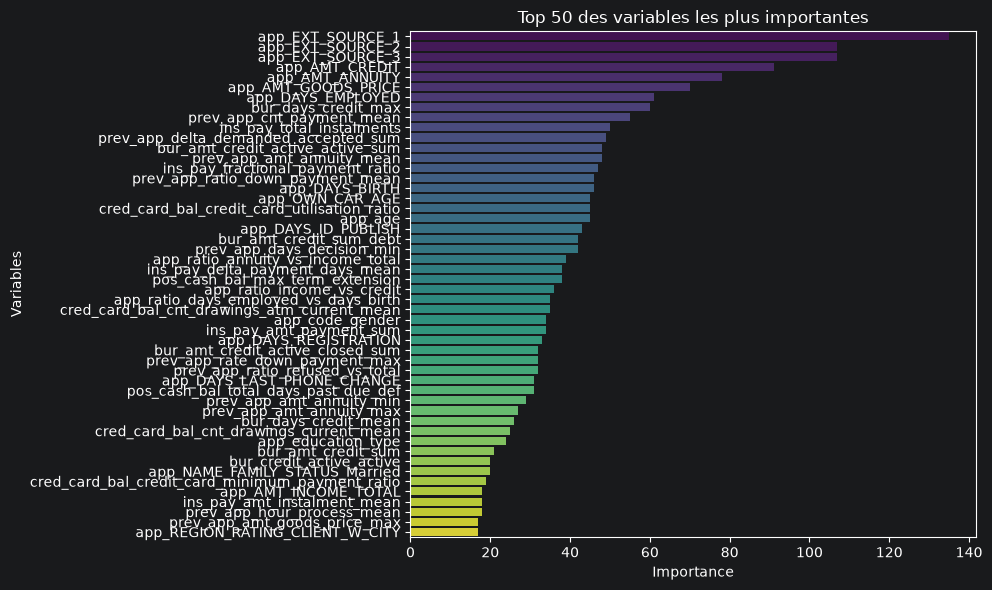

In [9]:
best_model = random_search.best_estimator_
importances = best_model.feature_importances_
features_names = best_model.feature_name_

utils.show_importances(importances, features_names, 50)